# Phase 7: equal-distance generic controls

This notebook tests every Phase-5 CM candidate against generic-real symplectic deformations at exactly matched RMS affine-invariant metric radii 0.02 and 0.10.

In [1]:
import gzip, json, math, statistics
from collections import defaultdict
from pathlib import Path

here = Path.cwd().resolve()
candidates = (here, here.parent, here / 'passive-cliffords')
project = next(path for path in candidates if (path / 'src' / 'gkp_passive_cliffords').exists())
data = project / 'data'
def load_json(name):
    path = data / name
    if path.exists(): return json.loads(path.read_text())
    with gzip.open(str(path) + '.gz', 'rt') as handle: return json.load(handle)
rows = load_json('phase7_equal_distance_controls.json')
summaries = load_json('phase7_equal_distance_controls_summary.json')
protocol = load_json('phase7_preregistered_protocol.json')
precision = load_json('phase7_high_precision_audit.json')
print(protocol['protocol_version'])
print(protocol['distance'])
print(f"Loaded {len(rows):,} controls for {len({r['candidate_id'] for r in rows}):,} CM candidates.")

phase7-v1-equal-geodesic-distance
RMS affine-invariant SPD distance: ||log(G0^-1/2 G1 G0^-1/2)||_F / sqrt(2g)
Loaded 24,990 controls for 4,165 CM candidates.


## Results by polarization type

The response is candidate-level $\Delta\ell^2=\operatorname{mean}(\ell^2_{\rm controls})-\ell^2_{\rm CM}$. Negative values favor CM.

In [2]:
print('type | radius | candidates | mean control-CM | 95% interval | mean ratio')
print('--- | --- | ---: | ---: | --- | ---:')
for row in summaries:
    interval = f"[{row['paired_difference_ci95_low']:.6f}, {row['paired_difference_ci95_high']:.6f}]"
    print(f"{tuple(row['polarization_type'])} | {row['target_rms_geodesic_distance']:.2f} | {row['candidate_count']} | {row['mean_paired_ell_difference']:.6f} | {interval} | {row['mean_candidate_control_to_cm_ratio']:.6f}")

type | radius | candidates | mean control-CM | 95% interval | mean ratio
--- | --- | ---: | ---: | --- | ---:
(1, 1, 2) | 0.10 | 1051 | -0.008823 | [-0.010037, -0.007609] | 0.990023
(1, 1, 2) | 0.02 | 1051 | -0.002158 | [-0.002413, -0.001903] | 0.997144
(1, 1, 3) | 0.10 | 1070 | -0.006641 | [-0.007761, -0.005521] | 0.990831
(1, 1, 3) | 0.02 | 1070 | -0.001666 | [-0.001902, -0.001430] | 0.997198
(1, 2, 2) | 0.10 | 253 | -0.009400 | [-0.011740, -0.007060] | 0.983274
(1, 2, 2) | 0.02 | 253 | -0.002224 | [-0.002719, -0.001729] | 0.995724
(1, 3) | 0.10 | 876 | -0.008233 | [-0.009352, -0.007113] | 0.985766
(1, 3) | 0.02 | 876 | -0.001779 | [-0.002018, -0.001540] | 0.996557
(1, 5) | 0.10 | 915 | -0.001670 | [-0.002347, -0.000993] | 0.999081
(1, 5) | 0.02 | 915 | -0.000452 | [-0.000595, -0.000310] | 0.999132


## Pooled candidate-level result

In [3]:
def candidate_level(control_rows):
    by_candidate = defaultdict(list)
    for row in control_rows:
        by_candidate[row['candidate_id']].append(row)
    differences, ratios, wins = [], [], []
    for candidate_rows in by_candidate.values():
        cm = candidate_rows[0]['cm_ell_squared']
        control = statistics.mean(row['control_ell_squared'] for row in candidate_rows)
        differences.append(control - cm)
        ratios.append(control / cm)
        wins.append(control > cm)
    average = statistics.mean(differences)
    se = statistics.stdev(differences) / math.sqrt(len(differences))
    return {
        'n': len(differences), 'mean_difference': average,
        'ci': (average - 1.96 * se, average + 1.96 * se),
        'mean_ratio': statistics.mean(ratios),
        'median_ratio': statistics.median(ratios),
        'control_mean_beats_fraction': statistics.mean(wins),
    }

for radius in ('near', 'far'):
    result = candidate_level([row for row in rows if row['radius_name'] == radius])
    print(radius, result)

near {'n': 4165, 'mean_difference': -0.0015811258572671469, 'ci': (-0.0016932632595746933, -0.0014689884549596004), 'mean_ratio': 0.9973849290932657, 'median_ratio': 0.99918040410175, 'control_mean_beats_fraction': 0.3793517406962785}
far {'n': 4165, 'mean_difference': -0.006601939644804889, 'ci': (-0.007132167246281528, -0.006071712043328251), 'mean_ratio': 0.9909152977174693, 'median_ratio': 0.9986351267159929, 'control_mean_beats_fraction': 0.45402160864345736}


## Dependence on passive symmetry

`Enhanced` means that the CM candidate's logical image is larger than the unavoidable generic image of $\{\pm I\}$.

In [4]:
for radius in ('near', 'far'):
    for enhanced in (False, True):
        selected = [
            row for row in rows
            if row['radius_name'] == radius
            and row['cm_has_enhanced_passive_symmetry'] is enhanced
        ]
        result = candidate_level(selected)
        print(radius, 'enhanced' if enhanced else 'minimal', result)

near minimal {'n': 3644, 'mean_difference': -0.0011288359037477614, 'ci': (-0.0012288679387054567, -0.0010288038687900662), 'mean_ratio': 0.9981377149924328, 'median_ratio': 0.9995823865335499, 'control_mean_beats_fraction': 0.4168496158068057}
near enhanced {'n': 521, 'mean_difference': -0.00474455117516473, 'ci': (-0.0052243071842929195, -0.00426479516603654), 'mean_ratio': 0.9921197624587849, 'median_ratio': 0.9927190408897186, 'control_mean_beats_fraction': 0.11708253358925144}
far minimal {'n': 3644, 'mean_difference': -0.00448606091126365, 'ci': (-0.004959539666005709, -0.004012582156521591), 'mean_ratio': 0.9946158417793296, 'median_ratio': 0.9999072401877411, 'control_mean_beats_fraction': 0.4964324917672887}
far enhanced {'n': 521, 'mean_difference': -0.021400907216828458, 'ci': (-0.023673162329225537, -0.01912865210443138), 'mean_ratio': 0.9650327975995832, 'median_ratio': 0.9678488545879562, 'control_mean_beats_fraction': 0.15738963531669867}


## Geometric and numerical validation

In [5]:
distance_error = max(abs(row['achieved_rms_geodesic_distance'] - row['target_rms_geodesic_distance']) for row in rows)
polarization_residual = max(row['polarization_residual'] for row in rows)
volume_residual = max(row['log_volume_residual'] for row in rows)
precision_error = max(row['absolute_difference'] for row in precision)
print('maximum target-radius error:', distance_error)
print('maximum polarization residual:', polarization_residual)
print('maximum log-volume residual:', volume_residual)
print('maximum 60-digit audit discrepancy:', precision_error)

maximum target-radius error: 1.9999491646105483e-11
maximum polarization residual: 5.684341886080802e-14
maximum log-volume residual: 8.615330671091215e-14
maximum 60-digit audit discrepancy: 1.1102230246251565e-16


## Radial profiles

These plots show the sense in which the CM points are elevated: radius zero is the CM baseline, while the marks at 0.02 and 0.10 are shell averages along the three sampled directions. They show average radial decline, not proof that every CM point is a strict local maximum in every direction.

<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:39: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:39: SyntaxWarning: invalid escape sequence '\e'
/var/folders/6n/xbpdfg2s7z5_z4t3j_8fzz7r0000gn/T/ipykernel_15075/1514279003.py:14: SyntaxWarning: invalid escape sequence '\e'
  ax.set(xlabel='RMS affine-invariant radius', ylabel='Mean control / CM $\ell^2$ (%)', title='Equal-distance radial profiles by polarization type')
/var/folders/6n/xbpdfg2s7z5_z4t3j_8fzz7r0000gn/T/ipykernel_15075/1514279003.py:39: SyntaxWarning: invalid escape sequence '\e'
  ax.set(xlabel='RMS affine-invariant radius', ylabel='Mean control / CM $\ell^2$ (%)', title='Radial decline is strongest around gate-enhanced CM points')


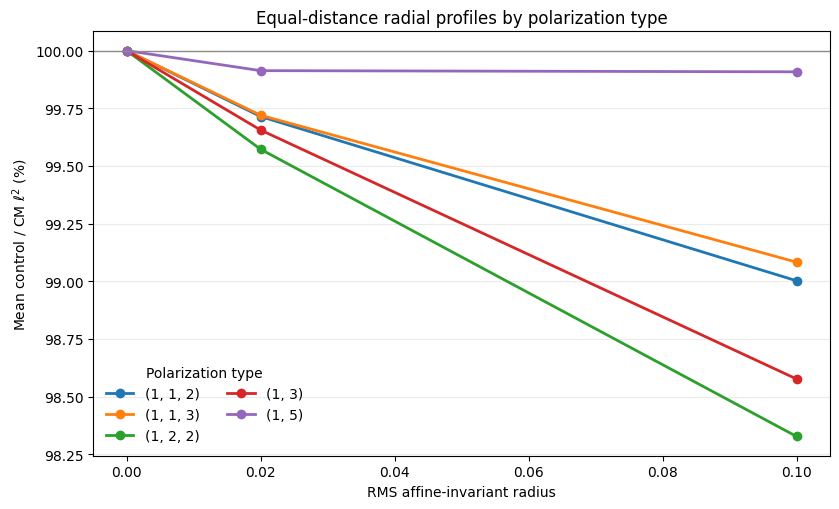

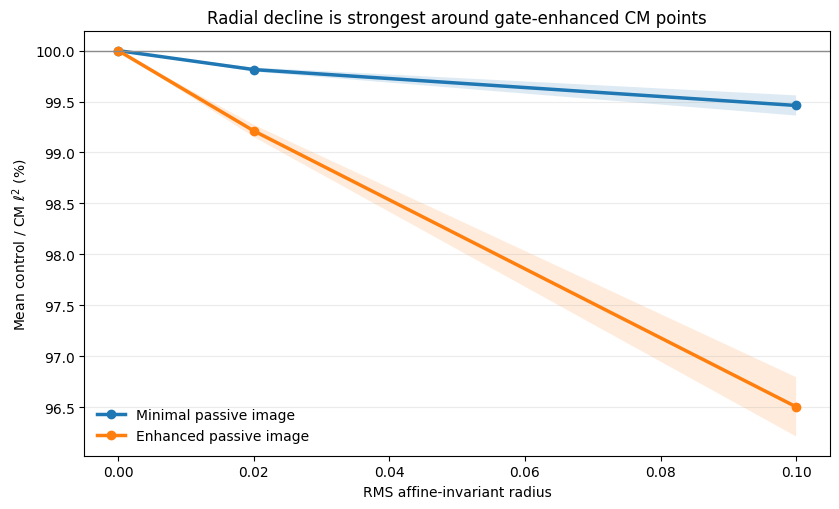

In [6]:
import matplotlib.pyplot as plt

figures = project / 'figures'
figures.mkdir(exist_ok=True)
radii = [0.0, 0.02, 0.10]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
for D in sorted({tuple(row['polarization_type']) for row in summaries}):
    near = next(row for row in summaries if tuple(row['polarization_type']) == D and row['radius_name'] == 'near')
    far = next(row for row in summaries if tuple(row['polarization_type']) == D and row['radius_name'] == 'far')
    values = [100.0, 100 * near['mean_candidate_control_to_cm_ratio'], 100 * far['mean_candidate_control_to_cm_ratio']]
    ax.plot(radii, values, marker='o', linewidth=2, label=str(D))
ax.axhline(100, color='0.55', linewidth=1)
ax.set(xlabel='RMS affine-invariant radius', ylabel='Mean control / CM $\ell^2$ (%)', title='Equal-distance radial profiles by polarization type')
ax.legend(title='Polarization type', frameon=False, ncols=2)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(figures / 'phase7_radial_profiles_by_type.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5.2))
for enhanced, label in ((False, 'Minimal passive image'), (True, 'Enhanced passive image')):
    values = [100.0]
    lower, upper = [100.0], [100.0]
    for radius_name in ('near', 'far'):
        selected = [row for row in rows if row['radius_name'] == radius_name and row['cm_has_enhanced_passive_symmetry'] is enhanced]
        by_candidate = defaultdict(list)
        for row in selected: by_candidate[row['candidate_id']].append(row)
        ratios = []
        for candidate_rows in by_candidate.values():
            cm = candidate_rows[0]['cm_ell_squared']
            ratios.append(statistics.mean(row['control_ell_squared'] for row in candidate_rows) / cm)
        average = statistics.mean(ratios)
        se = statistics.stdev(ratios) / math.sqrt(len(ratios))
        values.append(100 * average); lower.append(100 * (average - 1.96 * se)); upper.append(100 * (average + 1.96 * se))
    ax.plot(radii, values, marker='o', linewidth=2.5, label=label)
    ax.fill_between(radii, lower, upper, alpha=0.15)
ax.axhline(100, color='0.55', linewidth=1)
ax.set(xlabel='RMS affine-invariant radius', ylabel='Mean control / CM $\ell^2$ (%)', title='Radial decline is strongest around gate-enhanced CM points')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(figures / 'phase7_radial_profiles_by_symmetry.png', dpi=180, bbox_inches='tight')
plt.show()

## Reproducibility checks

In [7]:
assert protocol['adaptive_resampling'] is False
assert protocol['same_directions_at_both_radii'] is True
assert len(rows) == 24_990
assert len({row['candidate_id'] for row in rows}) == 4_165
assert distance_error < 2e-11
assert polarization_residual < 2e-9
assert volume_residual < 2e-9
assert precision_error < 2e-11
assert all(row['mean_paired_ell_difference'] < 0 for row in summaries)
assert all(row['paired_difference_ci95_high'] < 0 for row in summaries)
assert all(row['mean_paired_difference_enhanced_cm'] < row['mean_paired_difference_minimal_cm'] for row in summaries)
print('Phase 7 equal-distance checks passed.')

Phase 7 equal-distance checks passed.
